             meantemp   humidity  wind_speed  meanpressure
date                                                      
2013-01-01  10.000000  84.500000    0.000000   1015.666667
2013-01-02   7.400000  92.000000    2.980000   1017.800000
2013-01-03   7.166667  87.000000    4.633333   1018.666667
2013-01-04   8.666667  71.333333    1.233333   1017.166667
2013-01-05   6.000000  86.833333    3.700000   1016.500000
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB
None
          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802

C:\Users\shakt\AppData\Local\Temp\ipykernel_11304\789314754.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


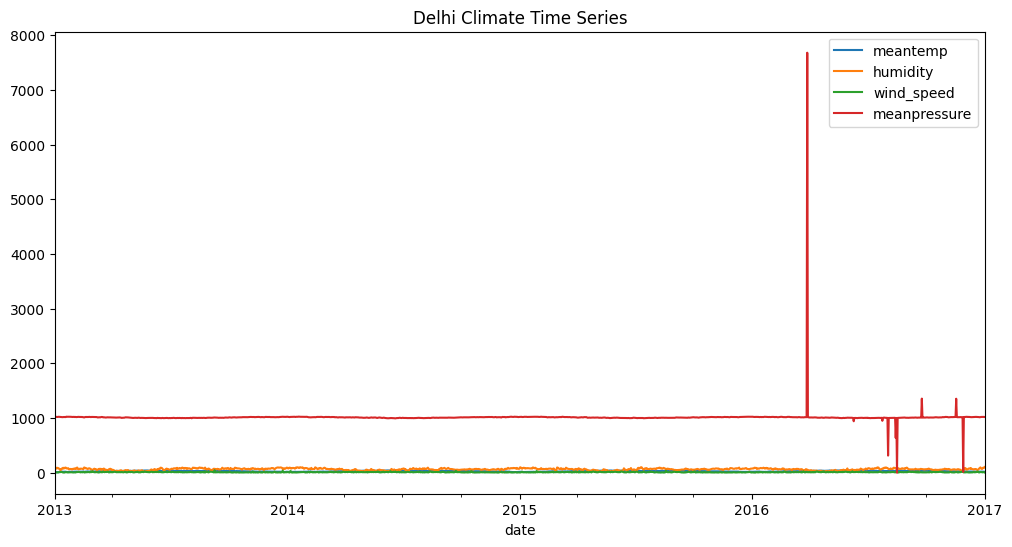

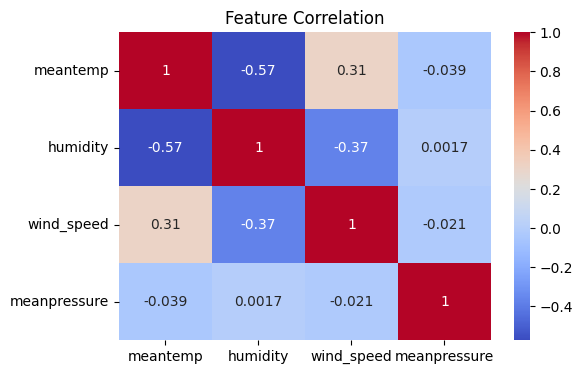

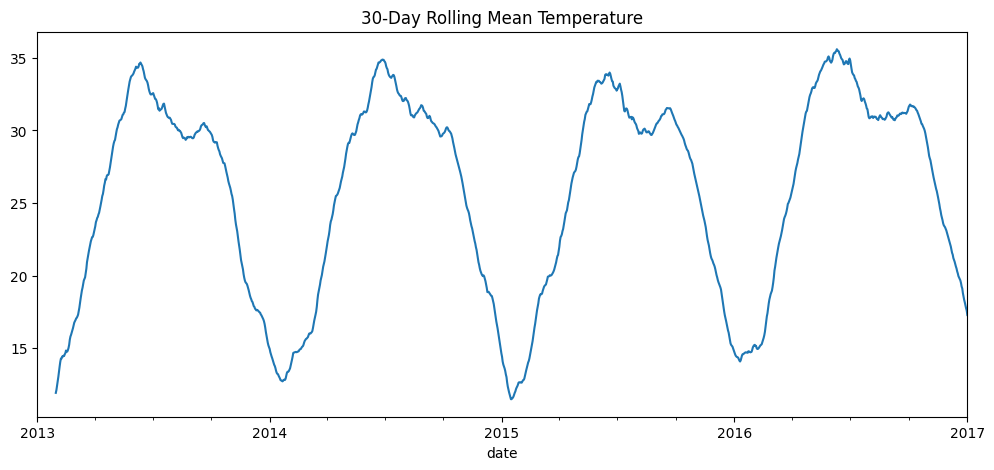

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"E:\AIML\DL_practice\DL_practice\DailyDelhiClimateTrain.csv")


df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


print(df.head())
print(df.info())
print(df.describe())


print("\nMissing Values:\n", df.isnull().sum())

df.fillna(method='ffill', inplace=True)


df.plot(figsize=(12,6), title="Delhi Climate Time Series")
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


df['meantemp'].rolling(window=30).mean().plot(figsize=(12,5), title="30-Day Rolling Mean Temperature")
plt.show()

e:\AIML\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
e:\AIML\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1506
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0081
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0062
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0058
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0056
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0056
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0055
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0053
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0054
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0052
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


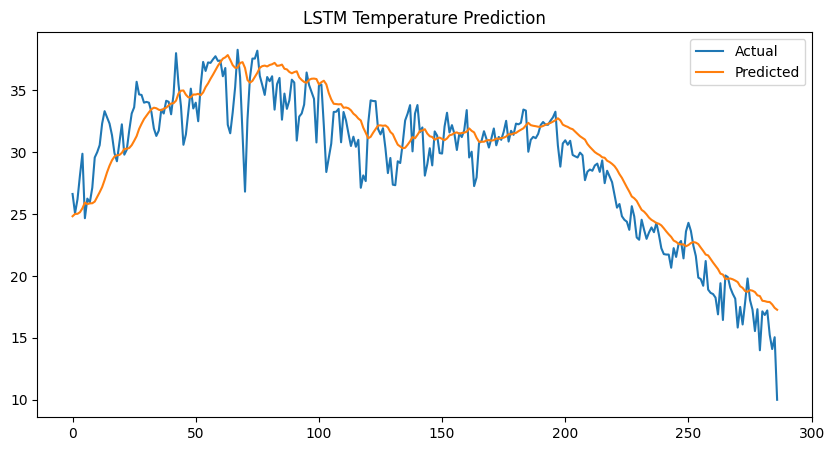

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import tensorflow as tf



df = pd.read_csv("DailyDelhiClimateTrain.csv")


data = df[['meantemp']].values


scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(data_scaled, seq_length)


split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, activation='relu', input_shape=(30,1)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Predict
predictions = model.predict(X_test)

# Inverse scaling
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Plot results
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("LSTM Temperature Prediction")
plt.show()